#### authors: Eva Ray, Massimo Stefani, Abdellah Jahjah

# Analysis of Distance Matrices Results

This notebook analyzes the distance matrices computed for climate similarity analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Load Distance Matrices

Function to load distance matrices based on method, distance type, period and scenario.

In [2]:
def load_distance_matrix(method, distance_type, period, scenario=None):
    """
    Load a distance matrix from CSV file.
    
    Parameters:
    -----------
    method : str
        Method used for distance calculation ('all', 'pca', 'embedding')
    distance_type : str
        Type of distance metric ('euclidean', 'mahalanobis')
    period : str
        Time period ('1940-1970' or '2021-2050')
    scenario : str, optional
        Climate scenario for future periods ('ssp126', 'ssp370', 'ssp585')
        Only required when period is '2021-2050'
    
    Returns:
    --------
    pd.DataFrame
        Distance matrix as a DataFrame
    """
    # Build filename
    if scenario:
        filename = f"{method}_{distance_type}_{period}_{scenario}.csv"
    else:
        filename = f"{method}_{distance_type}_{period}.csv"
    
    filepath = os.path.join("distance_matrices", filename)
    
    # Check if file exists
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")
    
    # Load the matrix
    df = pd.read_csv(filepath)
    
    return df


def load_all_matrices():
    """
    Load all available distance matrices into a dictionary.
    
    Returns:
    --------
    dict
        Dictionary with keys as tuples (method, distance_type, period, scenario)
        and values as DataFrames
    """
    matrices = {}
    
    methods = ['all', 'pca', 'embedding']
    distance_types = ['euclidean', 'mahalanobis']
    periods = ['1940-1970', '2021-2050']
    scenarios = [None, 'ssp126', 'ssp370', 'ssp585']
    
    # Load all combinations
    for method in methods:
        for distance_type in distance_types:
            for period in periods:
                if period == '1940-1970':
                    # Historical period - no scenario
                    try:
                        key = (method, distance_type, period, None)
                        matrices[key] = load_distance_matrix(method, distance_type, period)
                        print(f"Loaded: {method}_{distance_type}_{period}")
                    except FileNotFoundError as e:
                        print(f"Missing: {method}_{distance_type}_{period}")
                else:
                    # Future period - need scenario
                    for scenario in scenarios:
                        if scenario is None:
                            continue
                        try:
                            key = (method, distance_type, period, scenario)
                            matrices[key] = load_distance_matrix(method, distance_type, period, scenario)
                            print(f"Loaded: {method}_{distance_type}_{period}_{scenario}")
                        except FileNotFoundError as e:
                            print(f"Missing: {method}_{distance_type}_{period}_{scenario}")
    
    print(f"Total matrices loaded: {len(matrices)}")
    return matrices

## Load All Matrices

Load all available distance matrices into a dictionary.

In [3]:
# Load all distance matrices
matrices_dict = load_all_matrices()

Loaded: all_euclidean_1940-1970
Loaded: all_euclidean_2021-2050_ssp126
Loaded: all_euclidean_2021-2050_ssp370
Loaded: all_euclidean_2021-2050_ssp585
Loaded: all_mahalanobis_1940-1970
Loaded: all_mahalanobis_2021-2050_ssp126
Loaded: all_mahalanobis_2021-2050_ssp370
Loaded: all_mahalanobis_2021-2050_ssp585
Loaded: pca_euclidean_1940-1970
Loaded: pca_euclidean_2021-2050_ssp126
Loaded: pca_euclidean_2021-2050_ssp370
Loaded: pca_euclidean_2021-2050_ssp585
Loaded: pca_mahalanobis_1940-1970
Loaded: pca_mahalanobis_2021-2050_ssp126
Loaded: pca_mahalanobis_2021-2050_ssp370
Loaded: pca_mahalanobis_2021-2050_ssp585
Loaded: embedding_euclidean_1940-1970
Loaded: embedding_euclidean_2021-2050_ssp126
Loaded: embedding_euclidean_2021-2050_ssp370
Loaded: embedding_euclidean_2021-2050_ssp585
Loaded: embedding_mahalanobis_1940-1970
Loaded: embedding_mahalanobis_2021-2050_ssp126
Loaded: embedding_mahalanobis_2021-2050_ssp370
Loaded: embedding_mahalanobis_2021-2050_ssp585
Total matrices loaded: 24


In [4]:
# Load city names
cities_df = pd.read_csv("datasets/european_cities.csv")
city_names = cities_df['name'].tolist()

print(f"Number of cities: {len(city_names)}")
print(f"Sample cities: {city_names[:10]}")

Number of cities: 300
Sample cities: ['Aachen', 'Aberdeen', 'Aix-en-Provence', 'Alcalá de Henares', 'Alicante', 'Almería', 'Amersfoort', 'Amiens', 'Amsterdam', 'Angers']


## Distance ditribution

In [26]:
def plot_distance_distribution(distances, title_prefix="", figsize=(12, 5)):
    """
    Affiche la distribution des distances avec histogramme et boxplot.
    
    Parameters:
    -----------
    distances : array-like
        Tableau de distances à visualiser
    title_prefix : str, optional
        Préfixe à ajouter aux titres des graphiques
    figsize : tuple, optional
        Taille de la figure (largeur, hauteur)
    
    Returns:
    --------
    dict : Statistiques descriptives des distances
    """
    plt.figure(figsize=figsize)
    
    # Histogramme
    plt.subplot(1, 2, 1)
    plt.hist(distances, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel('Distance', fontsize=11)
    plt.ylabel('Fréquence', fontsize=11)
    plt.title(f'{title_prefix}Distribution des distances', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(distances, vert=True)
    plt.ylabel('Distance', fontsize=11)
    plt.title(f'{title_prefix}Boxplot des distances', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculer et afficher les statistiques
    stats = {
        'count': len(distances),
        'mean': np.mean(distances),
        'median': np.median(distances),
        'std': np.std(distances),
        'min': np.min(distances),
        'max': np.max(distances),
        'q25': np.percentile(distances, 25),
        'q75': np.percentile(distances, 75)
    }
    
    print(f"{title_prefix}Statistiques des distances:")
    print(f"  Nombre de distances: {stats['count']}")
    print(f"  Moyenne: {stats['mean']:.4f}")
    print(f"  Médiane: {stats['median']:.4f}")
    print(f"  Écart-type: {stats['std']:.4f}")
    print(f"  Min: {stats['min']:.4f}")
    print(f"  Max: {stats['max']:.4f}")
    print(f"  Q1 (25%): {stats['q25']:.4f}")
    print(f"  Q3 (75%): {stats['q75']:.4f}")
    
    return stats

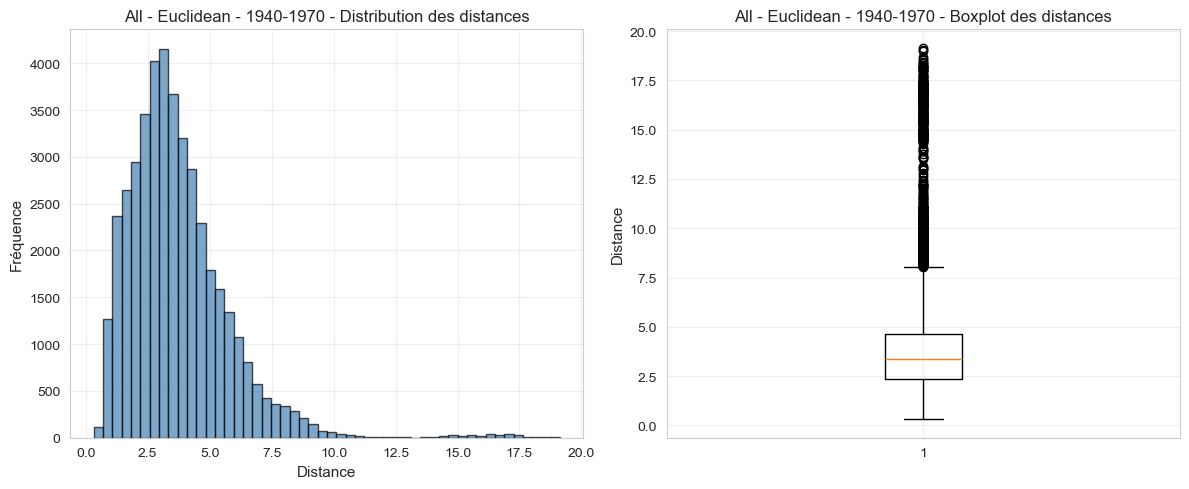

All - Euclidean - 1940-1970 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 3.7121
  Médiane: 3.3587
  Écart-type: 2.0571
  Min: 0.3197
  Max: 19.1410
  Q1 (25%): 2.3562
  Q3 (75%): 4.6372


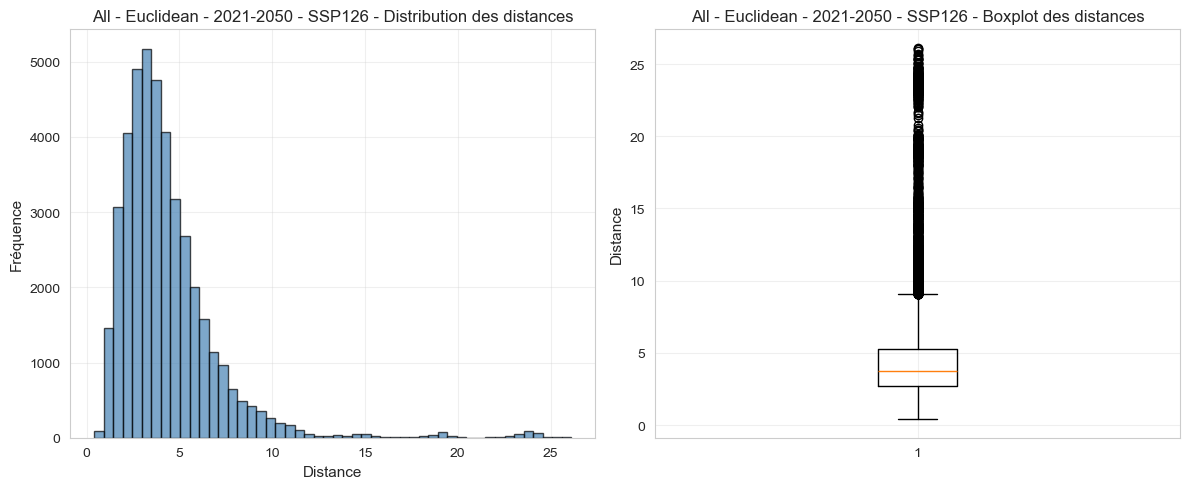

All - Euclidean - 2021-2050 - SSP126 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 4.3437
  Médiane: 3.7458
  Écart-type: 2.7933
  Min: 0.4045
  Max: 26.1206
  Q1 (25%): 2.6732
  Q3 (75%): 5.2371


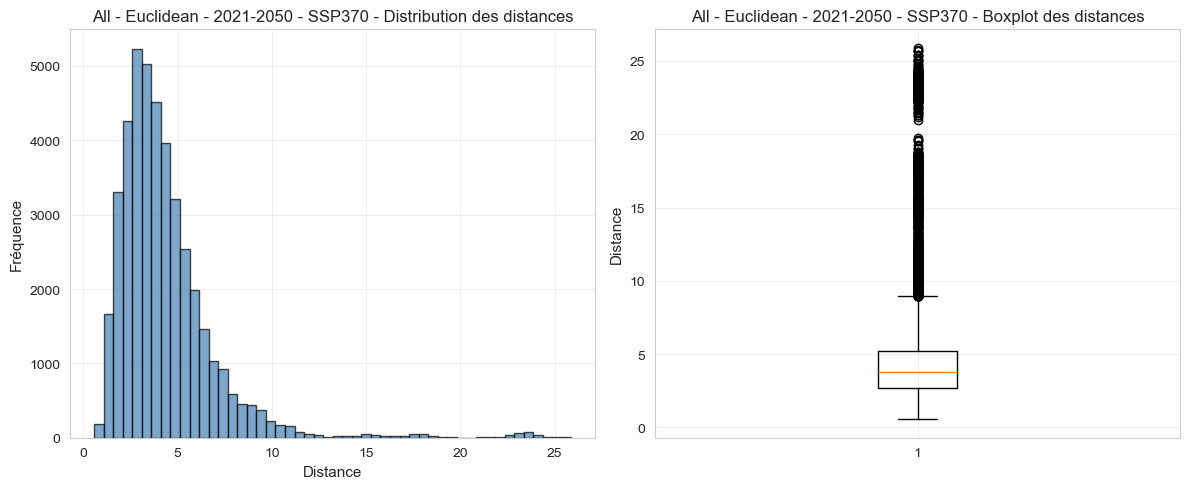

All - Euclidean - 2021-2050 - SSP370 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 4.3459
  Médiane: 3.7769
  Écart-type: 2.7109
  Min: 0.5676
  Max: 25.8835
  Q1 (25%): 2.7158
  Q3 (75%): 5.2120


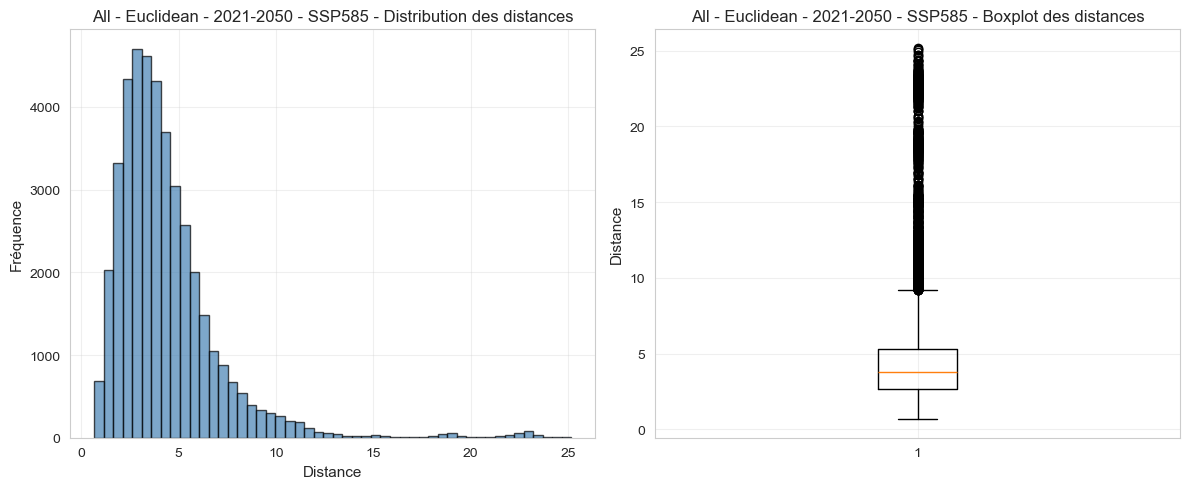

All - Euclidean - 2021-2050 - SSP585 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 4.3669
  Médiane: 3.7774
  Écart-type: 2.7846
  Min: 0.6637
  Max: 25.1816
  Q1 (25%): 2.6516
  Q3 (75%): 5.2796


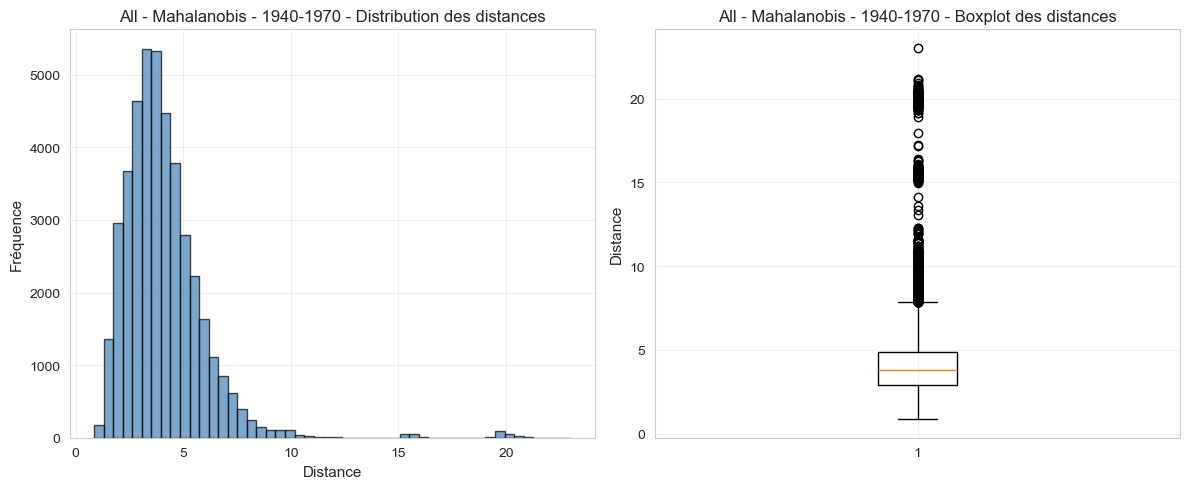

All - Mahalanobis - 1940-1970 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 4.0821
  Médiane: 3.7728
  Écart-type: 1.9623
  Min: 0.8610
  Max: 23.0333
  Q1 (25%): 2.8832
  Q3 (75%): 4.8661


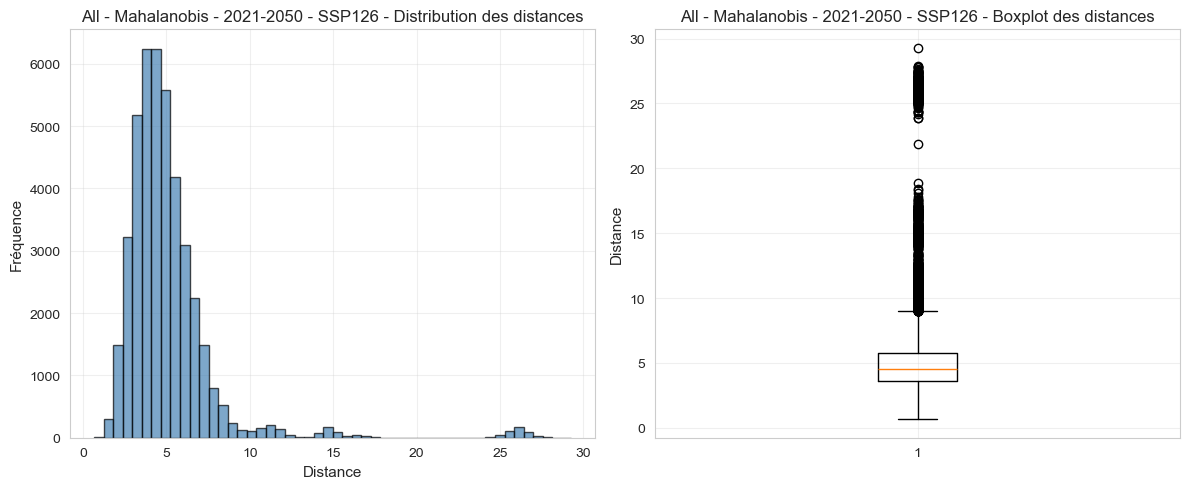

All - Mahalanobis - 2021-2050 - SSP126 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 5.0675
  Médiane: 4.5334
  Écart-type: 2.9415
  Min: 0.6666
  Max: 29.2761
  Q1 (25%): 3.5720
  Q3 (75%): 5.7356


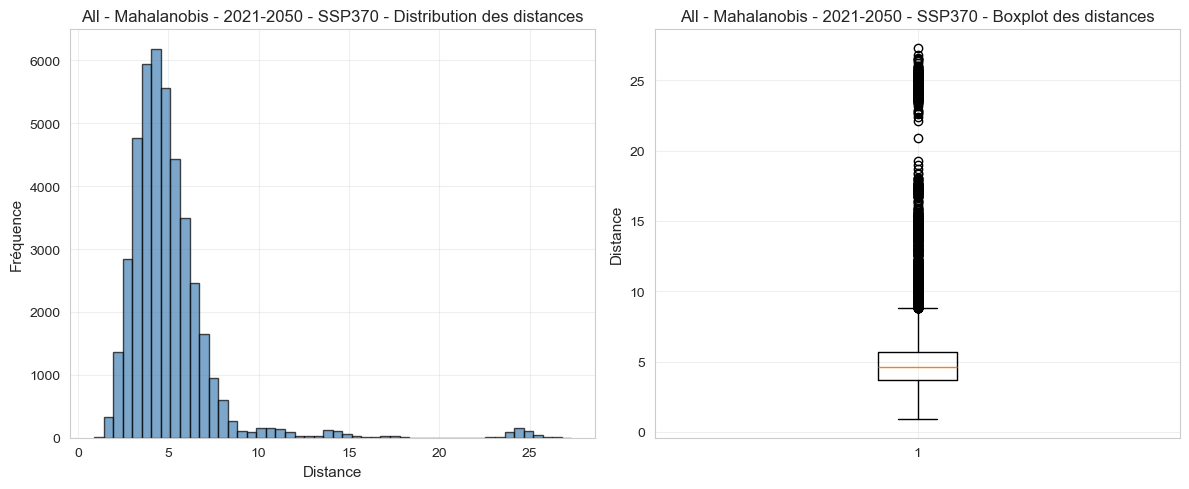

All - Mahalanobis - 2021-2050 - SSP370 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 5.0632
  Médiane: 4.5824
  Écart-type: 2.7496
  Min: 0.9009
  Max: 27.3075
  Q1 (25%): 3.6665
  Q3 (75%): 5.7105


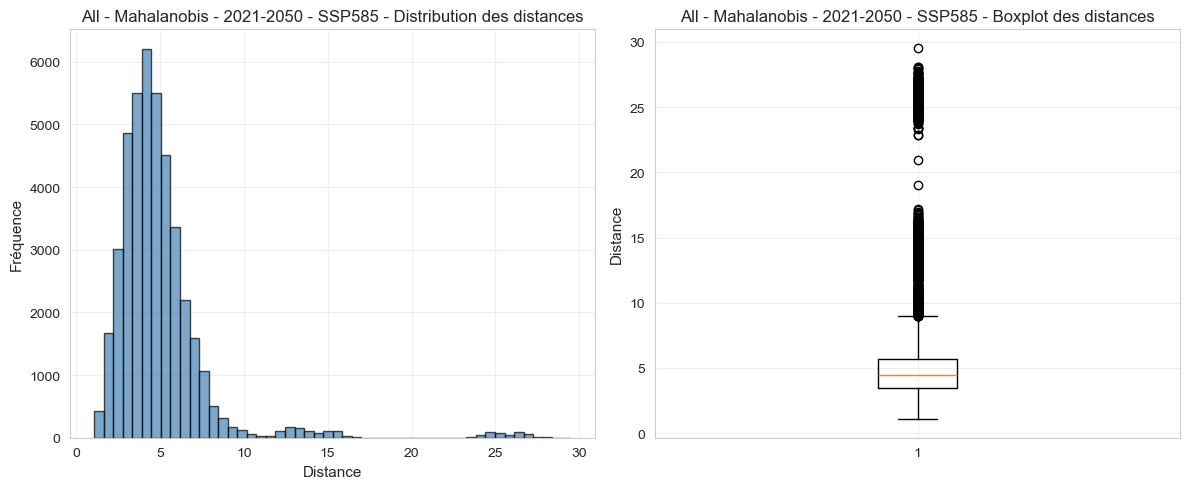

All - Mahalanobis - 2021-2050 - SSP585 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 4.9662
  Médiane: 4.4527
  Écart-type: 2.9680
  Min: 1.0766
  Max: 29.5334
  Q1 (25%): 3.4289
  Q3 (75%): 5.6573


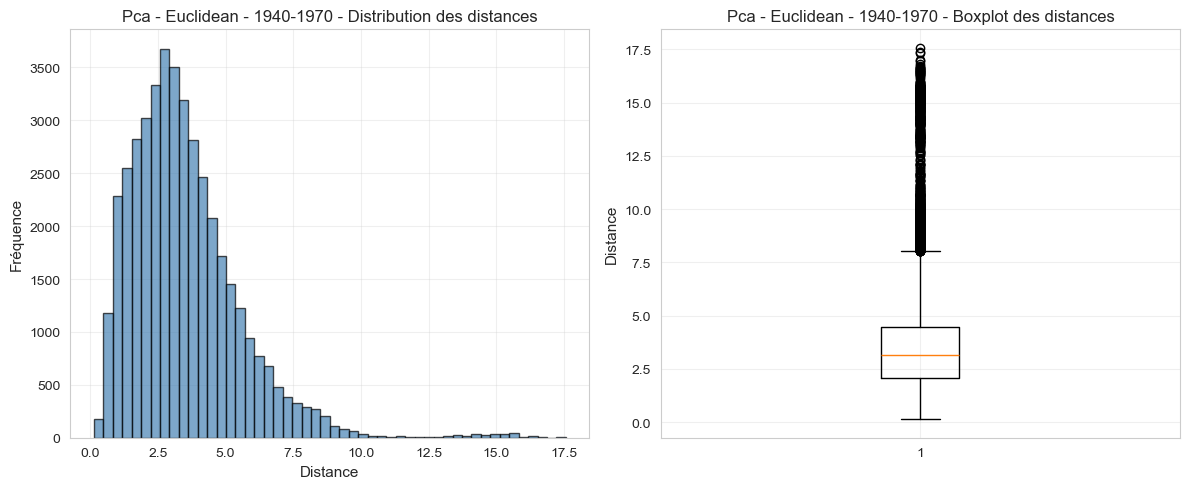

Pca - Euclidean - 1940-1970 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 3.4816
  Médiane: 3.1393
  Écart-type: 2.0336
  Min: 0.1391
  Max: 17.5666
  Q1 (25%): 2.0687
  Q3 (75%): 4.4620


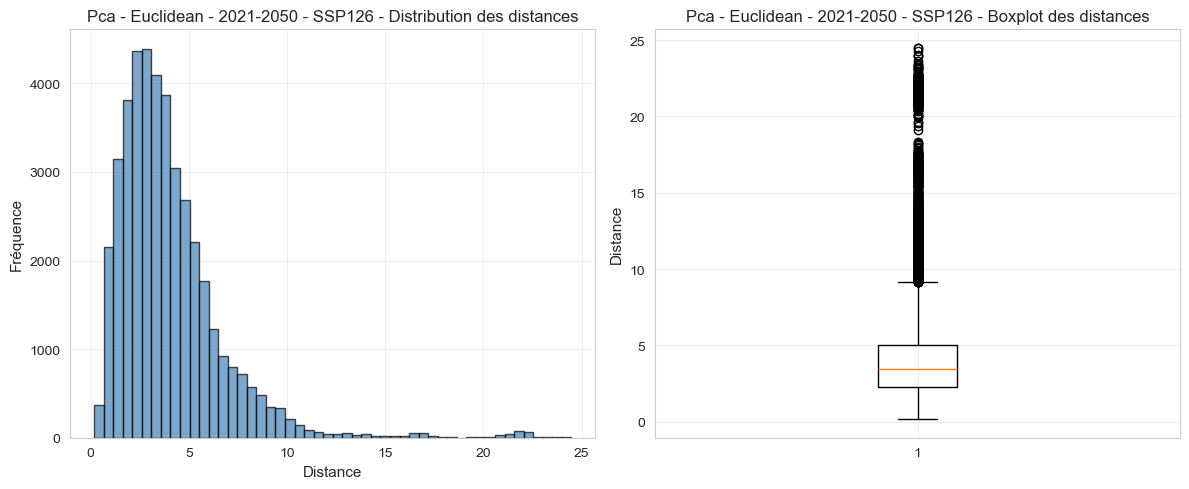

Pca - Euclidean - 2021-2050 - SSP126 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 4.0064
  Médiane: 3.4478
  Écart-type: 2.7397
  Min: 0.1743
  Max: 24.4838
  Q1 (25%): 2.2480
  Q3 (75%): 5.0232


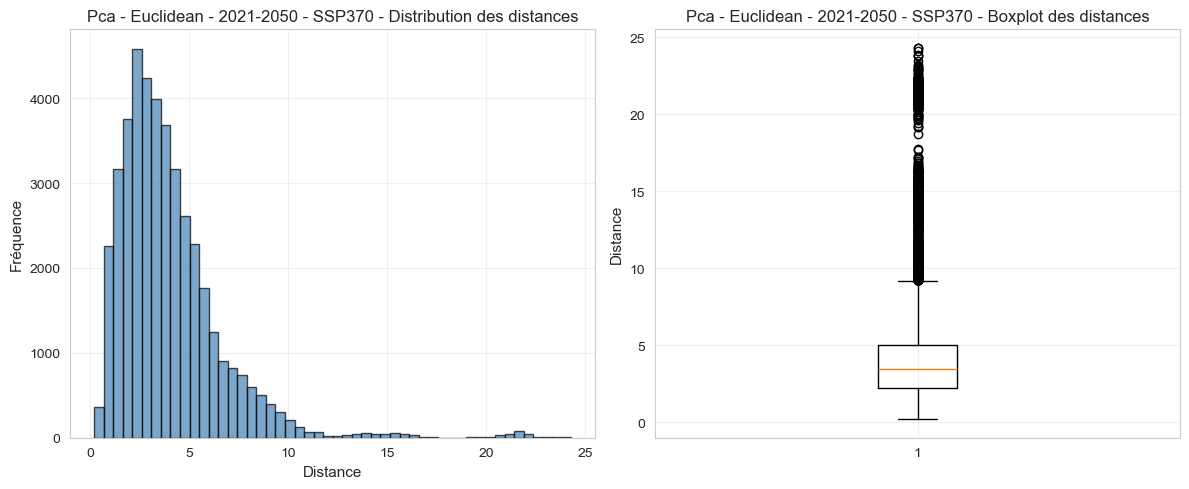

Pca - Euclidean - 2021-2050 - SSP370 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 3.9954
  Médiane: 3.4471
  Écart-type: 2.6926
  Min: 0.2069
  Max: 24.2959
  Q1 (25%): 2.2541
  Q3 (75%): 5.0344


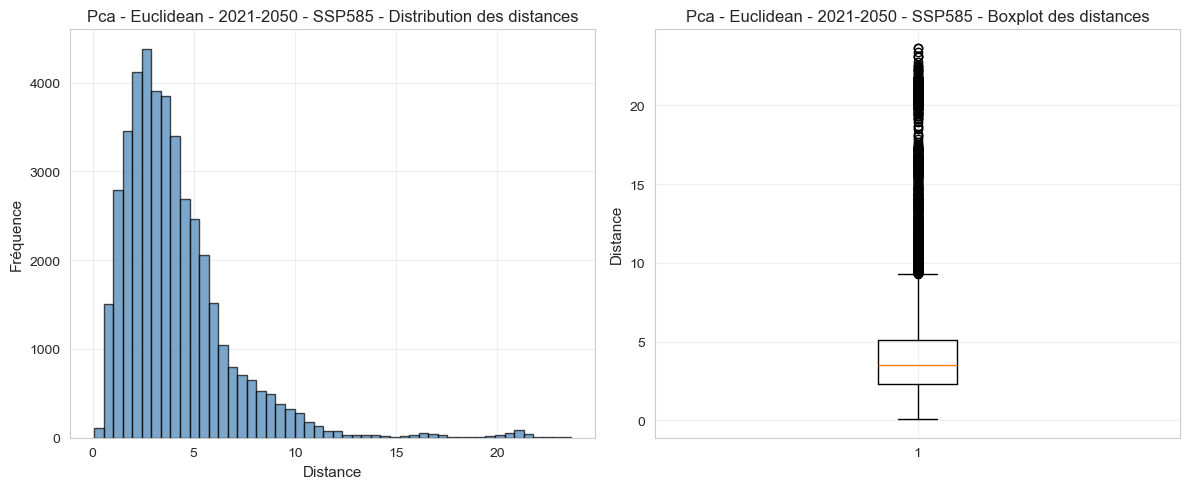

Pca - Euclidean - 2021-2050 - SSP585 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 4.0695
  Médiane: 3.4948
  Écart-type: 2.7294
  Min: 0.0793
  Max: 23.6509
  Q1 (25%): 2.2871
  Q3 (75%): 5.1032


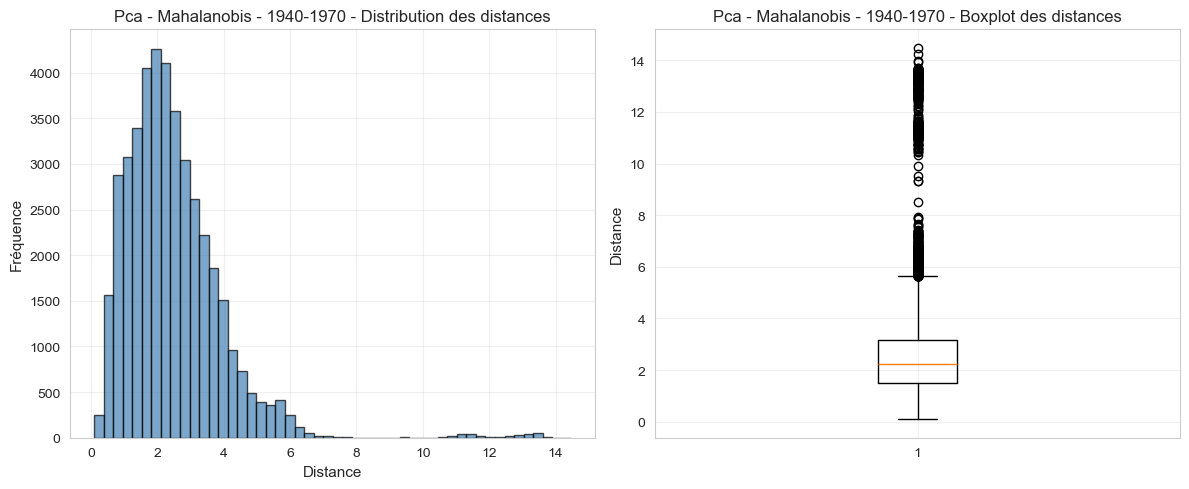

Pca - Mahalanobis - 1940-1970 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.4663
  Médiane: 2.2341
  Écart-type: 1.4722
  Min: 0.1018
  Max: 14.4758
  Q1 (25%): 1.4993
  Q3 (75%): 3.1538


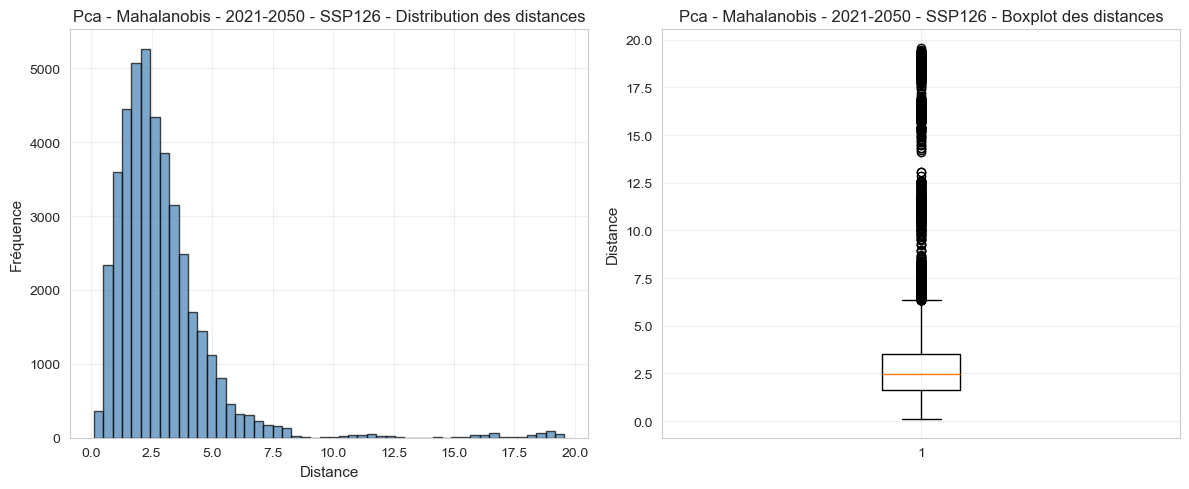

Pca - Mahalanobis - 2021-2050 - SSP126 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.8906
  Médiane: 2.4543
  Écart-type: 2.1816
  Min: 0.1053
  Max: 19.5652
  Q1 (25%): 1.6524
  Q3 (75%): 3.5333


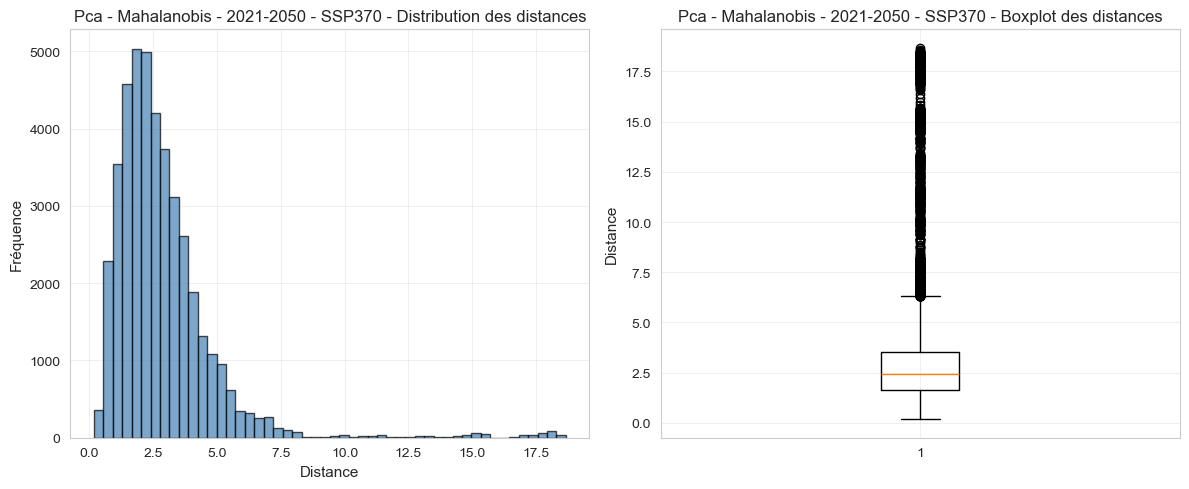

Pca - Mahalanobis - 2021-2050 - SSP370 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.8621
  Médiane: 2.4359
  Écart-type: 2.0854
  Min: 0.1798
  Max: 18.6721
  Q1 (25%): 1.6475
  Q3 (75%): 3.5100


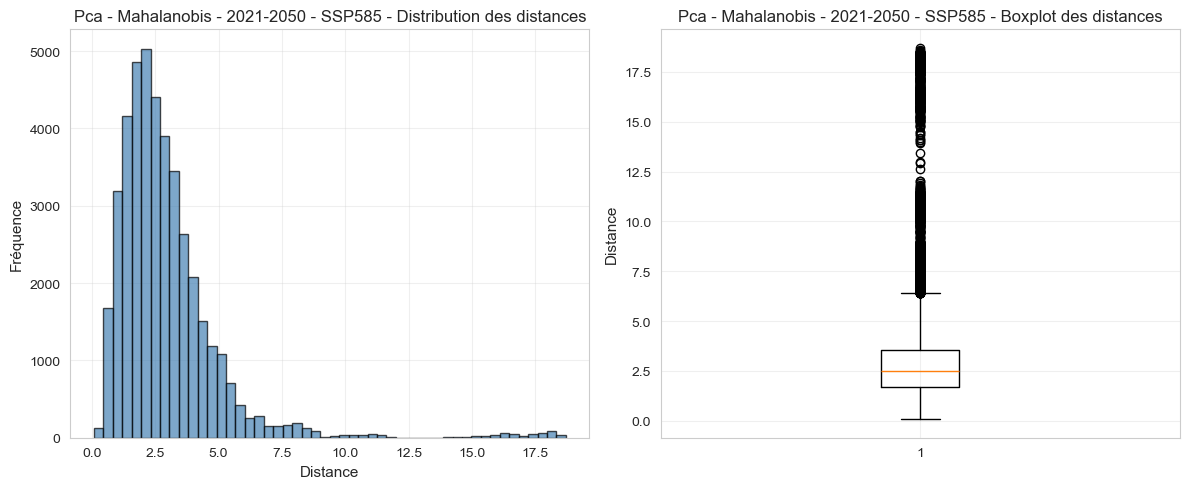

Pca - Mahalanobis - 2021-2050 - SSP585 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.9409
  Médiane: 2.4979
  Écart-type: 2.1481
  Min: 0.0821
  Max: 18.7007
  Q1 (25%): 1.6854
  Q3 (75%): 3.5762


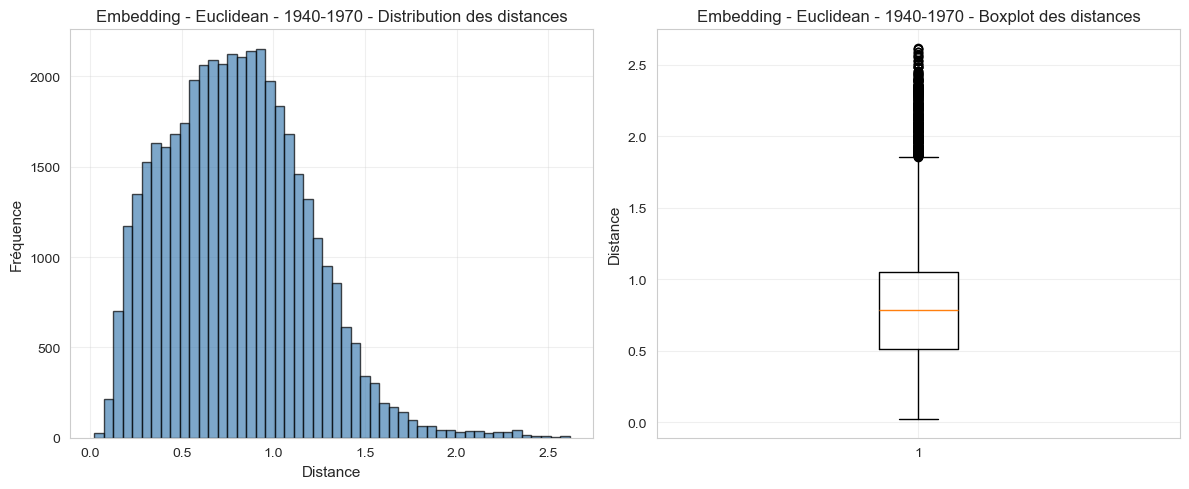

Embedding - Euclidean - 1940-1970 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 0.7998
  Médiane: 0.7811
  Écart-type: 0.3828
  Min: 0.0215
  Max: 2.6156
  Q1 (25%): 0.5105
  Q3 (75%): 1.0487


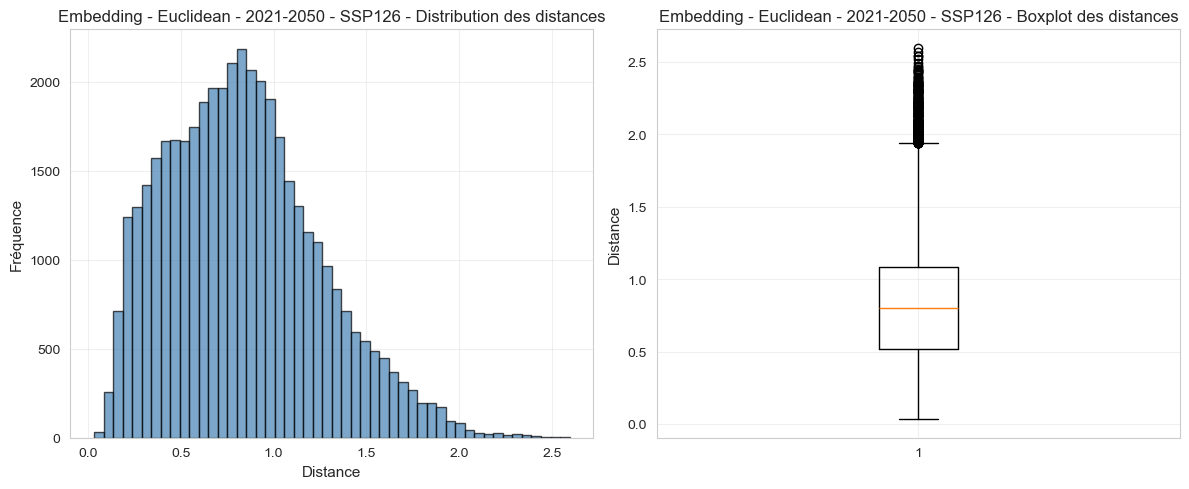

Embedding - Euclidean - 2021-2050 - SSP126 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 0.8335
  Médiane: 0.8029
  Écart-type: 0.4112
  Min: 0.0333
  Max: 2.5945
  Q1 (25%): 0.5179
  Q3 (75%): 1.0854


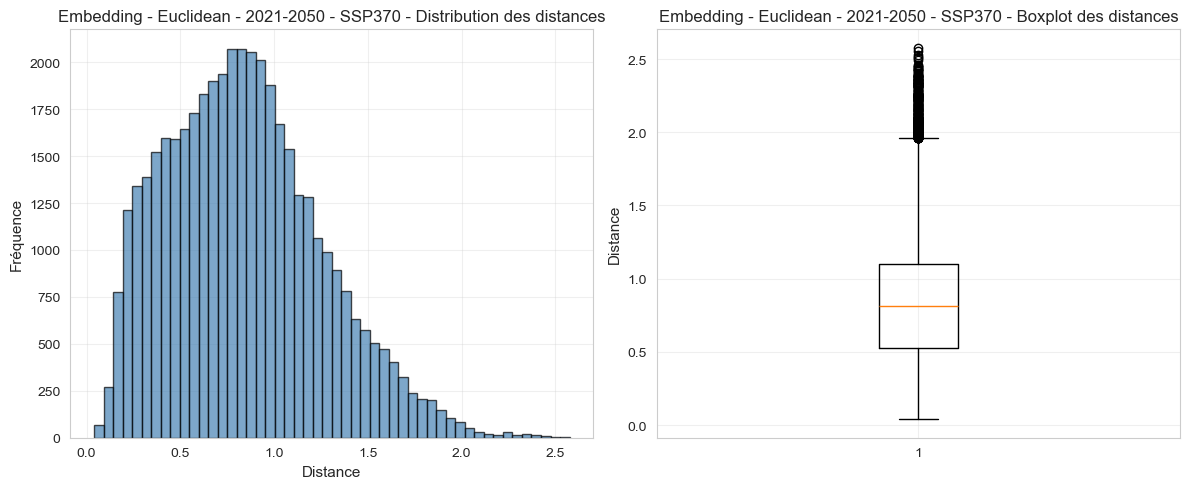

Embedding - Euclidean - 2021-2050 - SSP370 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 0.8390
  Médiane: 0.8096
  Écart-type: 0.4115
  Min: 0.0400
  Max: 2.5756
  Q1 (25%): 0.5227
  Q3 (75%): 1.0973


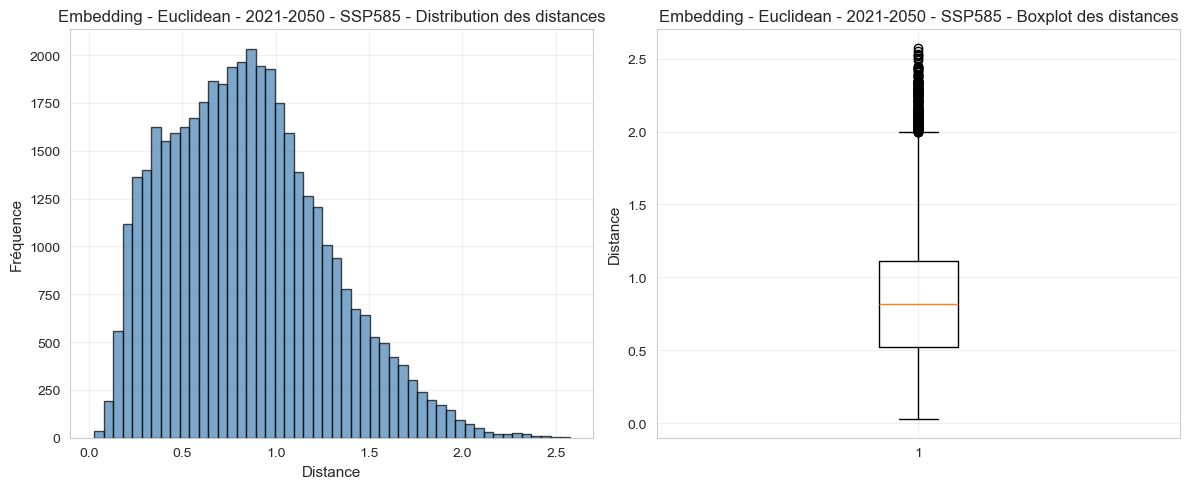

Embedding - Euclidean - 2021-2050 - SSP585 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 0.8489
  Médiane: 0.8191
  Écart-type: 0.4193
  Min: 0.0267
  Max: 2.5735
  Q1 (25%): 0.5226
  Q3 (75%): 1.1129


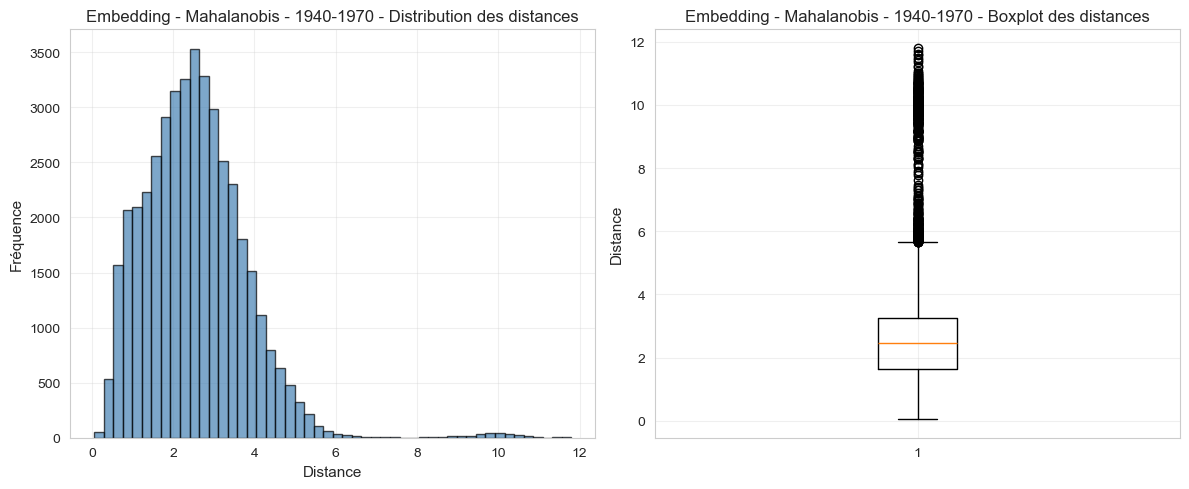

Embedding - Mahalanobis - 1940-1970 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.5396
  Médiane: 2.4553
  Écart-type: 1.2749
  Min: 0.0576
  Max: 11.7962
  Q1 (25%): 1.6592
  Q3 (75%): 3.2557


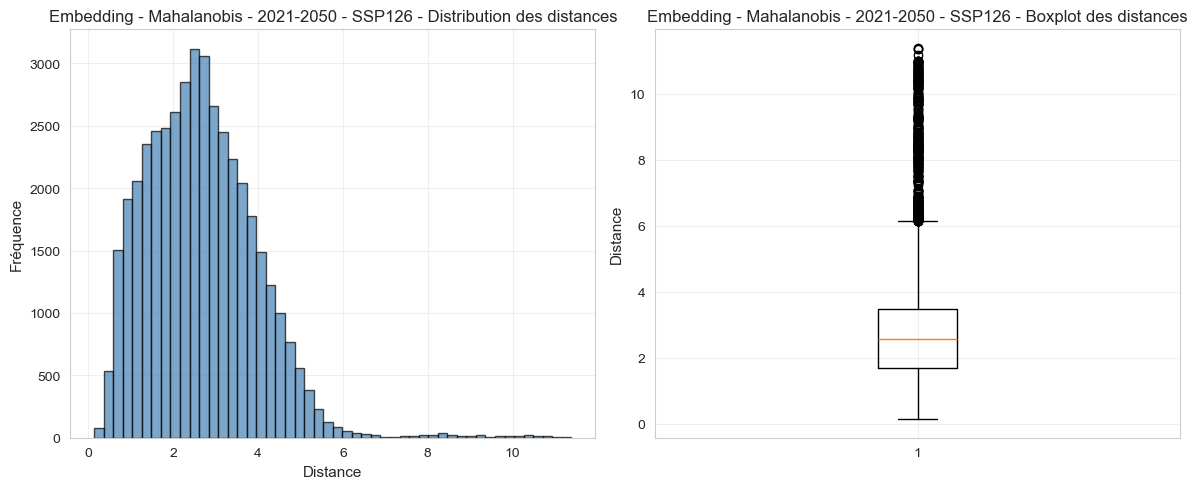

Embedding - Mahalanobis - 2021-2050 - SSP126 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.6565
  Médiane: 2.5626
  Écart-type: 1.3005
  Min: 0.1375
  Max: 11.3858
  Q1 (25%): 1.6875
  Q3 (75%): 3.4650


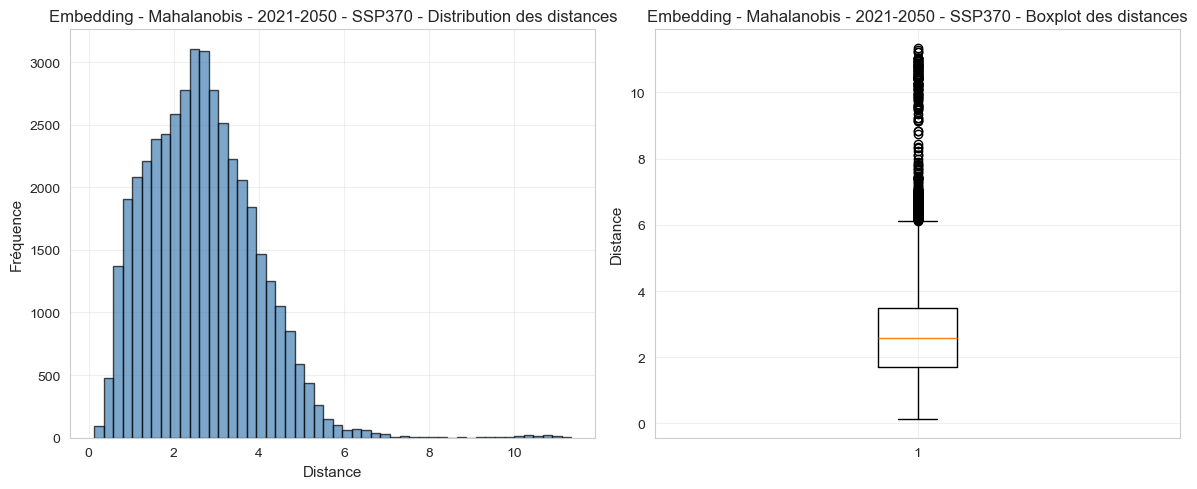

Embedding - Mahalanobis - 2021-2050 - SSP370 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.6684
  Médiane: 2.5852
  Écart-type: 1.2760
  Min: 0.1302
  Max: 11.3450
  Q1 (25%): 1.7093
  Q3 (75%): 3.4769


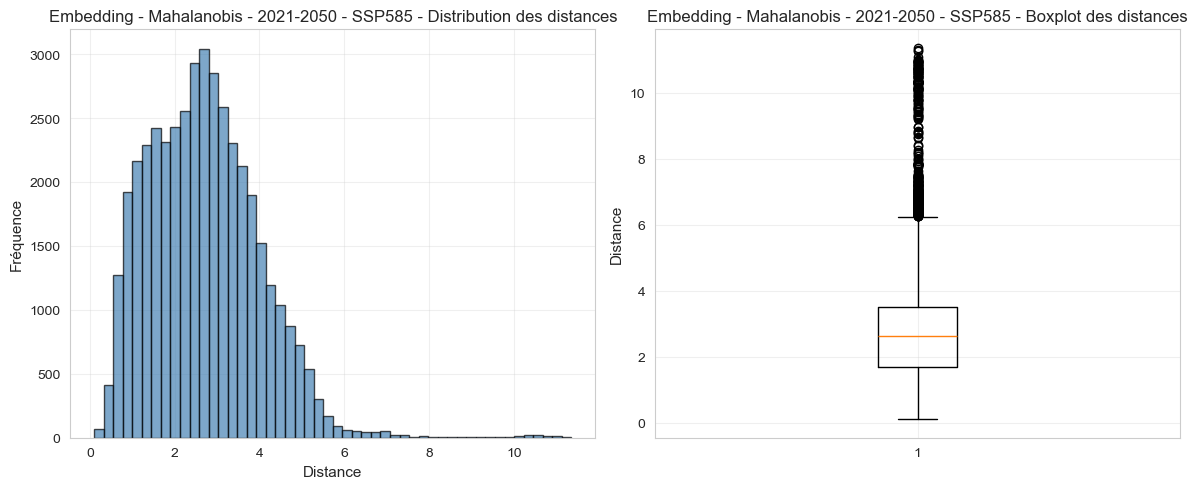

Embedding - Mahalanobis - 2021-2050 - SSP585 - Statistiques des distances:
  Nombre de distances: 42486
  Moyenne: 2.6856
  Médiane: 2.6109
  Écart-type: 1.3000
  Min: 0.1020
  Max: 11.3546
  Q1 (25%): 1.6843
  Q3 (75%): 3.5080


In [27]:
# Plot distance distributions for all loaded matrices

for key, df in matrices_dict.items():
    method, distance_type, period, scenario = key
    title_prefix = f"{method.capitalize()} - {distance_type.capitalize()} - {period}"
    if scenario:
        title_prefix += f" - {scenario.upper()}"
    
    # Extract distances (assuming the DataFrame is square and symmetric)
    distances = df.values[np.triu_indices_from(df.values, k=1)]
    
    # Plot distribution
    plot_distance_distribution(distances, title_prefix=title_prefix + " - ")

## Extract Top 5 Closest Cities for Each City

For each distance matrix, extract the 5 closest cities for every city.

In [5]:
def get_top_k_closest_cities(distance_matrix, city_names, k=5):
    """
    For each city (row), get the indices of the k closest cities.
    
    Parameters:
    -----------
    distance_matrix : pd.DataFrame
        Distance matrix where rows represent cities in the period
        and columns represent current cities (1994-2024)
    city_names : list
        List of city names corresponding to the columns
    k : int
        Number of closest cities to retrieve
    
    Returns:
    --------
    dict
        Dictionary where keys are city indices and values are lists of
        tuples (city_index, city_name, distance) for the k closest cities
    """
    top_k_cities = {}
    
    # For each row (city in the period)
    for row_idx in range(len(distance_matrix)):
        # Get distances for this city
        distances = distance_matrix.iloc[row_idx].values
        
        # Get indices sorted by distance (ascending)
        sorted_indices = np.argsort(distances)
        
        # Take top k (excluding the city itself if distance is 0)
        top_k_indices = []
        for idx in sorted_indices:
            if len(top_k_indices) >= k:
                break
            # Skip if distance is 0 or very small (likely the same city)
            if distances[idx] > 1e-10:
                top_k_indices.append(idx)
        
        # If we don't have enough cities (all were 0), take first k non-zero
        if len(top_k_indices) < k:
            top_k_indices = sorted_indices[:k]
        
        # Store results as (index, city_name, distance)
        top_k_cities[row_idx] = [
            (idx, city_names[idx], distances[idx]) 
            for idx in top_k_indices[:k]
        ]
    
    return top_k_cities


def extract_all_top_k(matrices_dict, city_names, k=5):
    """
    Extract top k closest cities for all matrices.
    
    Parameters:
    -----------
    matrices_dict : dict
        Dictionary of distance matrices
    city_names : list
        List of city names
    k : int
        Number of closest cities to retrieve
    
    Returns:
    --------
    dict
        Nested dictionary: {matrix_key: {city_idx: [(idx, name, distance), ...]}}
    """
    all_top_k = {}
    
    for key, matrix in matrices_dict.items():
        method, distance_type, period, scenario = key
        all_top_k[key] = get_top_k_closest_cities(matrix, city_names, k)
        print(f"Processed: {method}_{distance_type}_{period}" + 
              (f"_{scenario}" if scenario else ""))
    
    return all_top_k

In [6]:
# Extract top 5 closest cities for all matrices
top_k_results = extract_all_top_k(matrices_dict, city_names, k=5)

Processed: all_euclidean_1940-1970
Processed: all_euclidean_2021-2050_ssp126
Processed: all_euclidean_2021-2050_ssp370
Processed: all_euclidean_2021-2050_ssp585
Processed: all_mahalanobis_1940-1970
Processed: all_mahalanobis_2021-2050_ssp126
Processed: all_mahalanobis_2021-2050_ssp370
Processed: all_mahalanobis_2021-2050_ssp585
Processed: pca_euclidean_1940-1970
Processed: pca_euclidean_2021-2050_ssp126
Processed: pca_euclidean_2021-2050_ssp370
Processed: pca_euclidean_2021-2050_ssp585
Processed: pca_mahalanobis_1940-1970
Processed: pca_mahalanobis_2021-2050_ssp126
Processed: pca_mahalanobis_2021-2050_ssp370
Processed: pca_mahalanobis_2021-2050_ssp585
Processed: embedding_euclidean_1940-1970
Processed: embedding_euclidean_2021-2050_ssp126
Processed: embedding_euclidean_2021-2050_ssp370
Processed: embedding_euclidean_2021-2050_ssp585
Processed: embedding_mahalanobis_1940-1970
Processed: embedding_mahalanobis_2021-2050_ssp126
Processed: embedding_mahalanobis_2021-2050_ssp370
Processed: e

## Geographic Analysis: North-South Shift in Climate Analogs

Analyze the geographic trends to verify our hypotheses:
- Past (1940-1970): Climate analogs were colder, cities should be more to the North
- Future (2021-2050): Climate warming, climate analogs should shift South

In [7]:
def analyze_geographic_shift(top_k_results, city_names, cities_df):
    """
    Analyze the geographic distribution (latitude) of climate analogs
    for past vs future periods.
    
    For each city, calculate the mean latitude of its top 5 climate analogs
    in the past and future, then compare.
    
    Parameters:
    -----------
    top_k_results : dict
        Dictionary containing top k results
    city_names : list
        List of city names
    cities_df : pd.DataFrame
        DataFrame with city information including latitude
    
    Returns:
    --------
    dict
        Dictionary containing results for each method/distance/scenario
    """
    # Create a mapping from city name to latitude
    city_to_lat = dict(zip(cities_df['name'], cities_df['latitude']))
    
    results = {}
    
    methods = ['all', 'pca', 'embedding']
    distance_types = ['euclidean', 'mahalanobis']
    scenarios = ['ssp126', 'ssp370', 'ssp585']
    
    for method in methods:
        for distance_type in distance_types:
            # Historical period
            hist_key = (method, distance_type, '1940-1970', None)
            
            if hist_key not in top_k_results:
                continue
            
            hist_results = top_k_results[hist_key]
            
            for scenario in scenarios:
                # Future period
                future_key = (method, distance_type, '2021-2050', scenario)
                
                if future_key not in top_k_results:
                    continue
                
                future_results = top_k_results[future_key]
                
                # Calculate mean latitude of analogs for each city
                city_data = []
                
                for city_idx in hist_results.keys():
                    if city_idx not in future_results:
                        continue
                    
                    # Get reference city (from the period being analyzed)
                    ref_city_name = city_names[city_idx] if city_idx < len(city_names) else None
                    ref_lat = city_to_lat.get(ref_city_name, None)
                    
                    if ref_lat is None:
                        continue
                    
                    # Calculate mean latitude of historical analogs
                    hist_lats = []
                    for _, city_name, _ in hist_results[city_idx]:
                        lat = city_to_lat.get(city_name, None)
                        if lat is not None:
                            hist_lats.append(lat)
                    
                    # Calculate mean latitude of future analogs
                    future_lats = []
                    for _, city_name, _ in future_results[city_idx]:
                        lat = city_to_lat.get(city_name, None)
                        if lat is not None:
                            future_lats.append(lat)
                    
                    if hist_lats and future_lats:
                        mean_hist_lat = np.mean(hist_lats)
                        mean_future_lat = np.mean(future_lats)
                        
                        city_data.append({
                            'city_idx': city_idx,
                            'city_name': ref_city_name,
                            'reference_latitude': ref_lat,
                            'mean_analog_lat_past': mean_hist_lat,
                            'mean_analog_lat_future': mean_future_lat,
                            'lat_shift': mean_future_lat - mean_hist_lat,  # Negative = shift to South
                            'past_vs_reference': mean_hist_lat - ref_lat,  # Positive = analogs to North
                            'future_vs_reference': mean_future_lat - ref_lat  # Negative = analogs to South
                        })
                
                if city_data:
                    results[(method, distance_type, scenario)] = pd.DataFrame(city_data)
    
    return results

# Perform geographic analysis
geographic_results = analyze_geographic_shift(top_k_results, city_names, cities_df)

print(f"Analyzed geographic shifts for {len(geographic_results)} configurations")

Analyzed geographic shifts for 18 configurations


## Summary Statistics: Geographic Shifts

Let's summarize the geographic trends across all methods and scenarios.

In [8]:
def summarize_geographic_shifts(geographic_results):
    """
    Create summary statistics for all geographic shift analyses.
    """
    summary_data = []
    
    for key, df in geographic_results.items():
        method, distance_type, scenario = key
        
        summary_data.append({
            'method': method,
            'distance_type': distance_type,
            'scenario': scenario,
            'mean_past_shift': df['past_vs_reference'].mean(),
            'mean_future_shift': df['future_vs_reference'].mean(),
            'pct_past_north': (df['past_vs_reference'] > 0).sum() / len(df) * 100,
            'pct_future_south': (df['future_vs_reference'] < 0).sum() / len(df) * 100
        })
    
    return pd.DataFrame(summary_data)

# Create summary
geo_summary = summarize_geographic_shifts(geographic_results)

print("Geographic Shift Summary:")
print("="*80)
print("\nColumns explanation:")
print("- mean_past_shift: Mean latitude difference (analog cities - reference city) for 1940-1970")
print("- mean_future_shift: Mean latitude difference (analog cities - reference city) for 2021-2050")
print("- pct_past_north: % of cities where past analogs are to the NORTH (positive shift)")
print("- pct_future_south: % of cities where future analogs are to the SOUTH (negative shift)")
print("\n")
print(geo_summary.to_string(index=False))

print("\n" + "="*80)
print("HYPOTHESIS VERIFICATION:")
print("="*80)

# Calculate overall statistics
overall_past_shift = geo_summary['mean_past_shift'].mean()
overall_future_shift = geo_summary['mean_future_shift'].mean()
avg_pct_past_north = geo_summary['pct_past_north'].mean()
avg_pct_future_south = geo_summary['pct_future_south'].mean()

print(f"\n1. PAST (1940-1970) - Were analog cities to the NORTH (colder)?")
if overall_past_shift > 0:
    print(f"YES: Analog cities were on average {overall_past_shift:.2f} degrees latitude NORTH")
    print(f"{avg_pct_past_north:.1f}% of cities have northern analogs")
    print(f"Confirms hypothesis: past climate analogs were colder (northern cities)")
else:
    print(f"NO: Analog cities were on average {abs(overall_past_shift):.2f} degrees latitude SOUTH")
    print(f"{avg_pct_past_north:.1f}% of cities have northern analogs")

print(f"\n2. FUTURE (2021-2050) - Will analog cities be to the SOUTH (warmer)?")
if overall_future_shift < 0:
    print(f"YES: Analog cities are on average {abs(overall_future_shift):.2f} degrees latitude SOUTH")
    print(f"{avg_pct_future_south:.1f}% of cities have southern analogs")
    print(f"Confirms hypothesis: climate warming creates analogs in southern cities")
else:
    print(f"NO: Analog cities are on average {overall_future_shift:.2f} degrees latitude NORTH")
    print(f"{avg_pct_future_south:.1f}% of cities have southern analogs")

print(f"\n3. COMPARISON (Past vs Future):")
shift_difference = overall_past_shift - overall_future_shift
if shift_difference > 0:
    print(f"Climate analogs shift from NORTH (past) to SOUTH (future)")
    print(f"Difference: {shift_difference:.2f} degrees latitude")
    print(f"Consistent with warming trend")
else:
    print(f"Unexpected pattern detected")

print(f"\n4. CONSISTENCY ACROSS METHODS:")
print(f"Standard deviation of past shift: {geo_summary['mean_past_shift'].std():.2f} degrees")
print(f"Standard deviation of future shift: {geo_summary['mean_future_shift'].std():.2f} degrees")
if geo_summary['mean_past_shift'].std() < 1.0 and geo_summary['mean_future_shift'].std() < 1.0:
    print(f"All methods show consistent trends (low variability)")
else:
    print(f"Methods show some variability in results")

Geographic Shift Summary:

Columns explanation:
- mean_past_shift: Mean latitude difference (analog cities - reference city) for 1940-1970
- mean_future_shift: Mean latitude difference (analog cities - reference city) for 2021-2050
- pct_past_north: % of cities where past analogs are to the NORTH (positive shift)
- pct_future_south: % of cities where future analogs are to the SOUTH (negative shift)


   method distance_type scenario  mean_past_shift  mean_future_shift  pct_past_north  pct_future_south
      all     euclidean   ssp126         0.097572          -1.096067       46.232877         61.986301
      all     euclidean   ssp370         0.097572          -1.085810       46.232877         58.561644
      all     euclidean   ssp585         0.097572          -0.899794       46.232877         58.904110
      all   mahalanobis   ssp126        -0.811171          -1.754015       42.465753         62.671233
      all   mahalanobis   ssp370        -0.811171          -1.740596       42.465

## Visualize Geographic Shifts by Method and Scenario

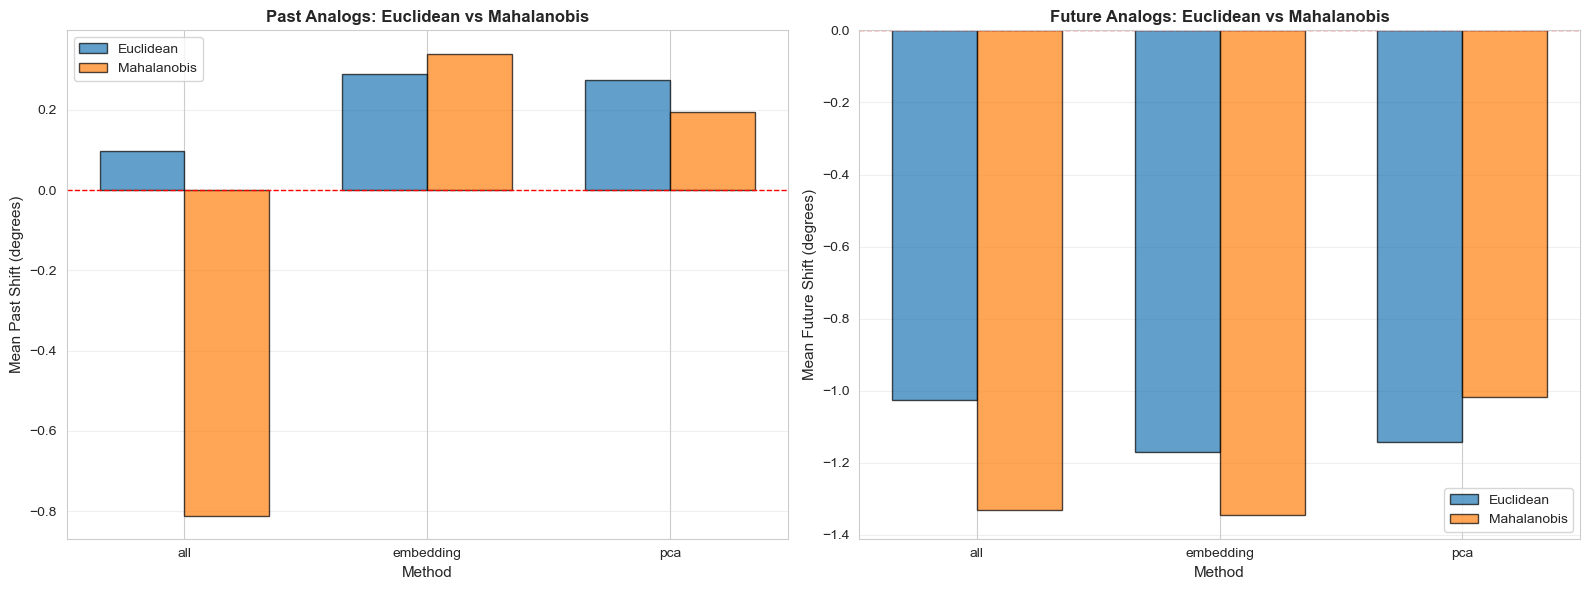

In [9]:
# 2. Comparison by method and distance type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Past shifts by method and distance type
ax1 = axes[0]
pivot_past = geo_summary.pivot_table(
    values='mean_past_shift',
    index='method',
    columns='distance_type',
    aggfunc='mean'
)
x = np.arange(len(pivot_past.index))
width = 0.35
ax1.bar(x - width/2, pivot_past['euclidean'].values, width, label='Euclidean', alpha=0.7, edgecolor='black')
ax1.bar(x + width/2, pivot_past['mahalanobis'].values, width, label='Mahalanobis', alpha=0.7, edgecolor='black')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_ylabel('Mean Past Shift (degrees)', fontsize=11)
ax1.set_xlabel('Method', fontsize=11)
ax1.set_title('Past Analogs: Euclidean vs Mahalanobis', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pivot_past.index)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Future shifts by method and distance type
ax2 = axes[1]
pivot_future = geo_summary.pivot_table(
    values='mean_future_shift',
    index='method',
    columns='distance_type',
    aggfunc='mean'
)
ax2.bar(x - width/2, pivot_future['euclidean'].values, width, label='Euclidean', alpha=0.7, edgecolor='black')
ax2.bar(x + width/2, pivot_future['mahalanobis'].values, width, label='Mahalanobis', alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Mean Future Shift (degrees)', fontsize=11)
ax2.set_xlabel('Method', fontsize=11)
ax2.set_title('Future Analogs: Euclidean vs Mahalanobis', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pivot_future.index)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

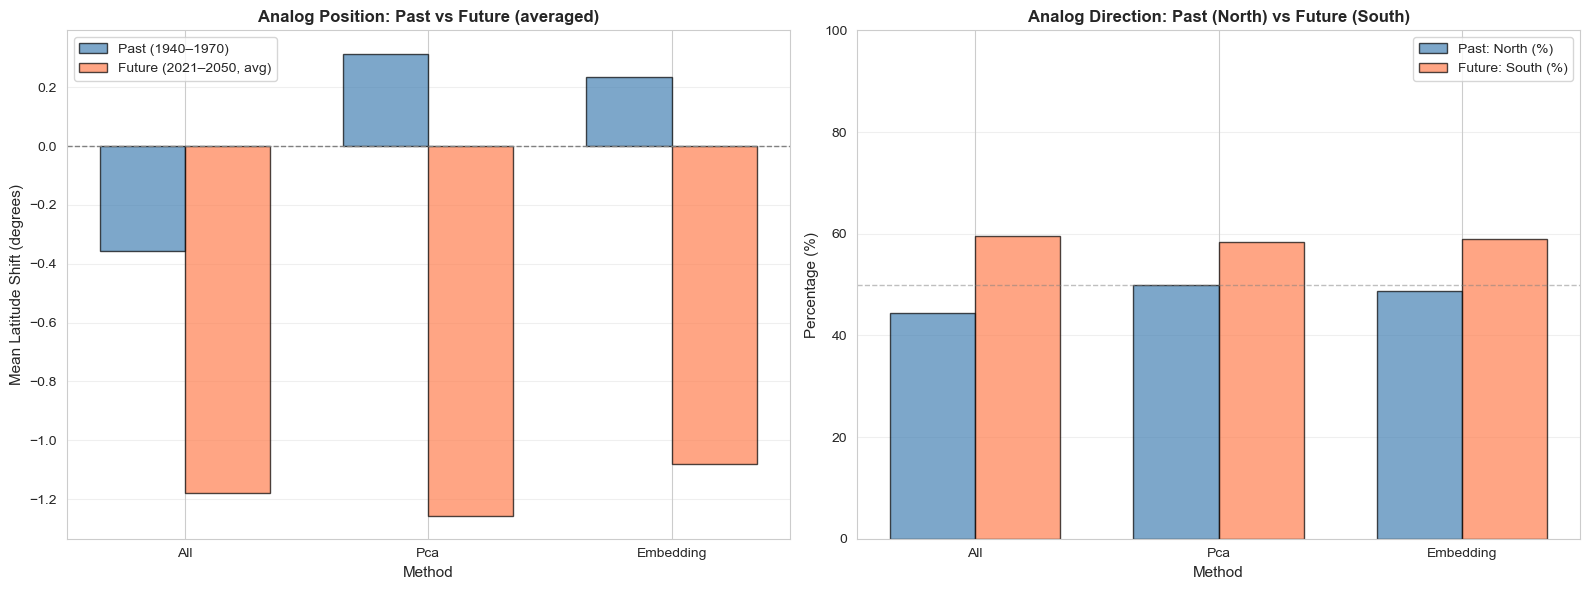

In [10]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]

methods = ['all', 'pca', 'embedding']
x = np.arange(len(methods))
width = 0.35

past_by_method = geo_summary.groupby('method')['mean_past_shift'].mean()
future_by_method = geo_summary.groupby('method')['mean_future_shift'].mean()

ax1.bar(
    x - width / 2,
    past_by_method.values,
    width,
    label='Past (1940–1970)',
    color='steelblue',
    alpha=0.7,
    edgecolor='black'
)

ax1.bar(
    x + width / 2,
    future_by_method.values,
    width,
    label='Future (2021–2050, avg)',
    color='coral',
    alpha=0.7,
    edgecolor='black'
)

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel('Mean Latitude Shift (degrees)', fontsize=11)
ax1.set_xlabel('Method', fontsize=11)
ax1.set_title(
    'Analog Position: Past vs Future (averaged)',
    fontsize=12,
    fontweight='bold'
)
ax1.set_xticks(x)
ax1.set_xticklabels([m.capitalize() for m in methods])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]

pct_past = geo_summary.groupby('method')['pct_past_north'].mean()
pct_future = geo_summary.groupby('method')['pct_future_south'].mean()

ax2.bar(
    x - width / 2,
    pct_past.values,
    width,
    label='Past: North (%)',
    color='steelblue',
    alpha=0.7,
    edgecolor='black'
)

ax2.bar(
    x + width / 2,
    pct_future.values,
    width,
    label='Future: South (%)',
    color='coral',
    alpha=0.7,
    edgecolor='black'
)

ax2.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('Percentage (%)', fontsize=11)
ax2.set_xlabel('Method', fontsize=11)
ax2.set_title(
    'Analog Direction: Past (North) vs Future (South)',
    fontsize=12,
    fontweight='bold'
)
ax2.set_xticks(x)
ax2.set_xticklabels([m.capitalize() for m in methods])
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [11]:
geo_summary.groupby('method')['mean_future_shift'].mean()

method
all         -1.179201
embedding   -1.256491
pca         -1.080732
Name: mean_future_shift, dtype: float64

In [12]:
geo_summary.groupby('method')['mean_past_shift'].mean()

method
all         -0.356800
embedding    0.314997
pca          0.234529
Name: mean_past_shift, dtype: float64

In [13]:
geo_summary.groupby('method')['pct_past_north'].mean()

method
all          44.349315
embedding    50.000000
pca          48.801370
Name: pct_past_north, dtype: float64

In [14]:
geo_summary.groupby('method')['pct_future_south'].mean()

method
all          59.531963
embedding    58.447489
pca          58.961187
Name: pct_future_south, dtype: float64

In [15]:
geo_summary['pct_past_south'] = 100 - geo_summary['pct_past_north']

print("PASSÉ - Distribution Nord/Sud par méthode:")
print("\nPourcentage au NORD:")
print(geo_summary.groupby('method')['pct_past_north'].mean())
print("\nPourcentage au SUD:")
print(geo_summary.groupby('method')['pct_past_south'].mean())

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print(f"Les ~52% restants (qui ne sont pas au Nord) sont bien au SUD")
print(f"Donc pour le passé: environ 48% Nord, 52% Sud")
print(f"Pour le futur: environ 41% Nord, 59% Sud")
print(f"\n→ CHANGEMENT: De 48%N/52%S (quasi-équilibre) à 41%N/59%S (tendance Sud)")

PASSÉ - Distribution Nord/Sud par méthode:

Pourcentage au NORD:
method
all          44.349315
embedding    50.000000
pca          48.801370
Name: pct_past_north, dtype: float64

Pourcentage au SUD:
method
all          55.650685
embedding    50.000000
pca          51.198630
Name: pct_past_south, dtype: float64

CONCLUSION:
Les ~52% restants (qui ne sont pas au Nord) sont bien au SUD
Donc pour le passé: environ 48% Nord, 52% Sud
Pour le futur: environ 41% Nord, 59% Sud

→ CHANGEMENT: De 48%N/52%S (quasi-équilibre) à 41%N/59%S (tendance Sud)


## Analyse avec le MEILLEUR analogue (k=1) au lieu de la moyenne de 5

Calculons maintenant avec k=1 pour voir combien de villes ont **elles-mêmes** comme meilleur analogue climatique (= pas de changement).

In [16]:
# Extraire le TOP 1 (meilleur analogue uniquement)
top_1_results = extract_all_top_k(matrices_dict, city_names, k=1)

Processed: all_euclidean_1940-1970
Processed: all_euclidean_2021-2050_ssp126
Processed: all_euclidean_2021-2050_ssp370
Processed: all_euclidean_2021-2050_ssp585
Processed: all_mahalanobis_1940-1970
Processed: all_mahalanobis_2021-2050_ssp126
Processed: all_mahalanobis_2021-2050_ssp370
Processed: all_mahalanobis_2021-2050_ssp585
Processed: pca_euclidean_1940-1970
Processed: pca_euclidean_2021-2050_ssp126
Processed: pca_euclidean_2021-2050_ssp370
Processed: pca_euclidean_2021-2050_ssp585
Processed: pca_mahalanobis_1940-1970
Processed: pca_mahalanobis_2021-2050_ssp126
Processed: pca_mahalanobis_2021-2050_ssp370
Processed: pca_mahalanobis_2021-2050_ssp585
Processed: embedding_euclidean_1940-1970
Processed: embedding_euclidean_2021-2050_ssp126
Processed: embedding_euclidean_2021-2050_ssp370
Processed: embedding_euclidean_2021-2050_ssp585
Processed: embedding_mahalanobis_1940-1970
Processed: embedding_mahalanobis_2021-2050_ssp126
Processed: embedding_mahalanobis_2021-2050_ssp370
Processed: e

In [17]:
def analyze_best_analog_shift(top_1_results, city_names, cities_df):
    """
    Analyse la position géographique du MEILLEUR analogue (k=1).
    Permet de voir si une ville a elle-même comme meilleur analogue (pas de changement).
    """
    city_to_lat = dict(zip(cities_df['name'], cities_df['latitude']))
    
    results = {}
    
    methods = ['all', 'pca', 'embedding']
    distance_types = ['euclidean', 'mahalanobis']
    scenarios = ['ssp126', 'ssp370', 'ssp585']
    
    for method in methods:
        for distance_type in distance_types:
            # Historical period
            hist_key = (method, distance_type, '1940-1970', None)
            
            if hist_key not in top_1_results:
                continue
            
            hist_results = top_1_results[hist_key]
            
            for scenario in scenarios:
                # Future period
                future_key = (method, distance_type, '2021-2050', scenario)
                
                if future_key not in top_1_results:
                    continue
                
                future_results = top_1_results[future_key]
                
                city_data = []
                
                for city_idx in hist_results.keys():
                    if city_idx not in future_results:
                        continue
                    
                    ref_city_name = city_names[city_idx] if city_idx < len(city_names) else None
                    ref_lat = city_to_lat.get(ref_city_name, None)
                    
                    if ref_lat is None:
                        continue
                    
                    # Meilleur analogue historique
                    best_hist_idx, best_hist_name, best_hist_dist = hist_results[city_idx][0]
                    hist_lat = city_to_lat.get(best_hist_name, None)
                    
                    # Meilleur analogue futur
                    best_future_idx, best_future_name, best_future_dist = future_results[city_idx][0]
                    future_lat = city_to_lat.get(best_future_name, None)
                    
                    if hist_lat is not None and future_lat is not None:
                        city_data.append({
                            'city_idx': city_idx,
                            'city_name': ref_city_name,
                            'reference_latitude': ref_lat,
                            'best_analog_past': best_hist_name,
                            'best_analog_past_lat': hist_lat,
                            'best_analog_future': best_future_name,
                            'best_analog_future_lat': future_lat,
                            'past_shift': hist_lat - ref_lat,
                            'future_shift': future_lat - ref_lat,
                            'is_same_past': (best_hist_name == ref_city_name),  # Analogue = soi-même?
                            'is_same_future': (best_future_name == ref_city_name)
                        })
                
                if city_data:
                    results[(method, distance_type, scenario)] = pd.DataFrame(city_data)
    
    return results

geo_results_k1 = analyze_best_analog_shift(top_1_results, city_names, cities_df)

print(f"Analysé {len(geo_results_k1)} configurations avec le meilleur analogue (k=1)")

Analysé 18 configurations avec le meilleur analogue (k=1)


In [18]:
def summarize_best_analog(geo_results_k1):
    """
    Créer un résumé des statistiques pour les meilleurs analogues (k=1).
    """
    summary_data = []
    
    for key, df in geo_results_k1.items():
        method, distance_type, scenario = key
        
        summary_data.append({
            'method': method,
            'distance_type': distance_type,
            'scenario': scenario,
            'mean_past_shift': df['past_shift'].mean(),
            'mean_future_shift': df['future_shift'].mean(),
            'pct_same_past': df['is_same_past'].sum() / len(df) * 100,
            'pct_same_future': df['is_same_future'].sum() / len(df) * 100,
            'pct_past_north': (df['past_shift'] > 0).sum() / len(df) * 100,
            'pct_past_south': (df['past_shift'] < 0).sum() / len(df) * 100,
            'pct_future_north': (df['future_shift'] > 0).sum() / len(df) * 100,
            'pct_future_south': (df['future_shift'] < 0).sum() / len(df) * 100
        })
    
    return pd.DataFrame(summary_data)

# Créer le résumé
geo_summary_k1 = summarize_best_analog(geo_results_k1)

print("="*80)
print("ANALYSE AVEC LE MEILLEUR ANALOGUE (k=1)")
print("="*80)
print("\nColonnes:")
print("- pct_same_past/future: % de villes ayant ELLES-MÊMES comme meilleur analogue")
print("- pct_past/future_north: % de villes avec analogue au NORD")
print("- pct_past/future_south: % de villes avec analogue au SUD")
print("\n")
print(geo_summary_k1.to_string(index=False))

print("\n" + "="*80)
print("STATISTIQUES GLOBALES:")
print("="*80)

avg_same_past = geo_summary_k1['pct_same_past'].mean()
avg_same_future = geo_summary_k1['pct_same_future'].mean()
avg_north_past = geo_summary_k1['pct_past_north'].mean()
avg_south_past = geo_summary_k1['pct_past_south'].mean()
avg_north_future = geo_summary_k1['pct_future_north'].mean()
avg_south_future = geo_summary_k1['pct_future_south'].mean()

print(f"\nPASSÉ (1940-1970):")
print(f"  Villes identiques (meilleur analogue = soi-même): {avg_same_past:.1f}%")
print(f"  Villes avec analogue au NORD: {avg_north_past:.1f}%")
print(f"  Villes avec analogue au SUD: {avg_south_past:.1f}%")

print(f"\nFUTUR (2021-2050):")
print(f"  Villes identiques (meilleur analogue = soi-même): {avg_same_future:.1f}%")
print(f"  Villes avec analogue au NORD: {avg_north_future:.1f}%")
print(f"  Villes avec analogue au SUD: {avg_south_future:.1f}%")

print(f"\n" + "="*80)
print("INTERPRÉTATION:")
print("="*80)
if avg_same_past > 0:
    print(f"✓ {avg_same_past:.1f}% des villes n'ont PAS changé climatiquement (passé)")
else:
    print(f"✗ AUCUNE ville n'a conservé son climat identique (passé)")
    
if avg_same_future > 0:
    print(f"✓ {avg_same_future:.1f}% des villes resteront climatiquement stables (futur)")
else:
    print(f"✗ AUCUNE ville ne conservera son climat actuel (futur)")
    print(f"   → {avg_south_future:.1f}% auront un climat plus chaud (analogues au Sud)")

ANALYSE AVEC LE MEILLEUR ANALOGUE (k=1)

Colonnes:
- pct_same_past/future: % de villes ayant ELLES-MÊMES comme meilleur analogue
- pct_past/future_north: % de villes avec analogue au NORD
- pct_past/future_south: % de villes avec analogue au SUD


   method distance_type scenario  mean_past_shift  mean_future_shift  pct_same_past  pct_same_future  pct_past_north  pct_past_south  pct_future_north  pct_future_south
      all     euclidean   ssp126        -0.051160          -0.913314      33.219178        13.356164       33.561644       33.219178         35.958904         50.684932
      all     euclidean   ssp370        -0.051160          -0.732688      33.219178        14.383562       33.561644       33.219178         38.013699         47.602740
      all     euclidean   ssp585        -0.051160          -0.588116      33.219178        10.958904       33.561644       33.219178         39.383562         49.657534
      all   mahalanobis   ssp126        -1.045689          -2.067826      24

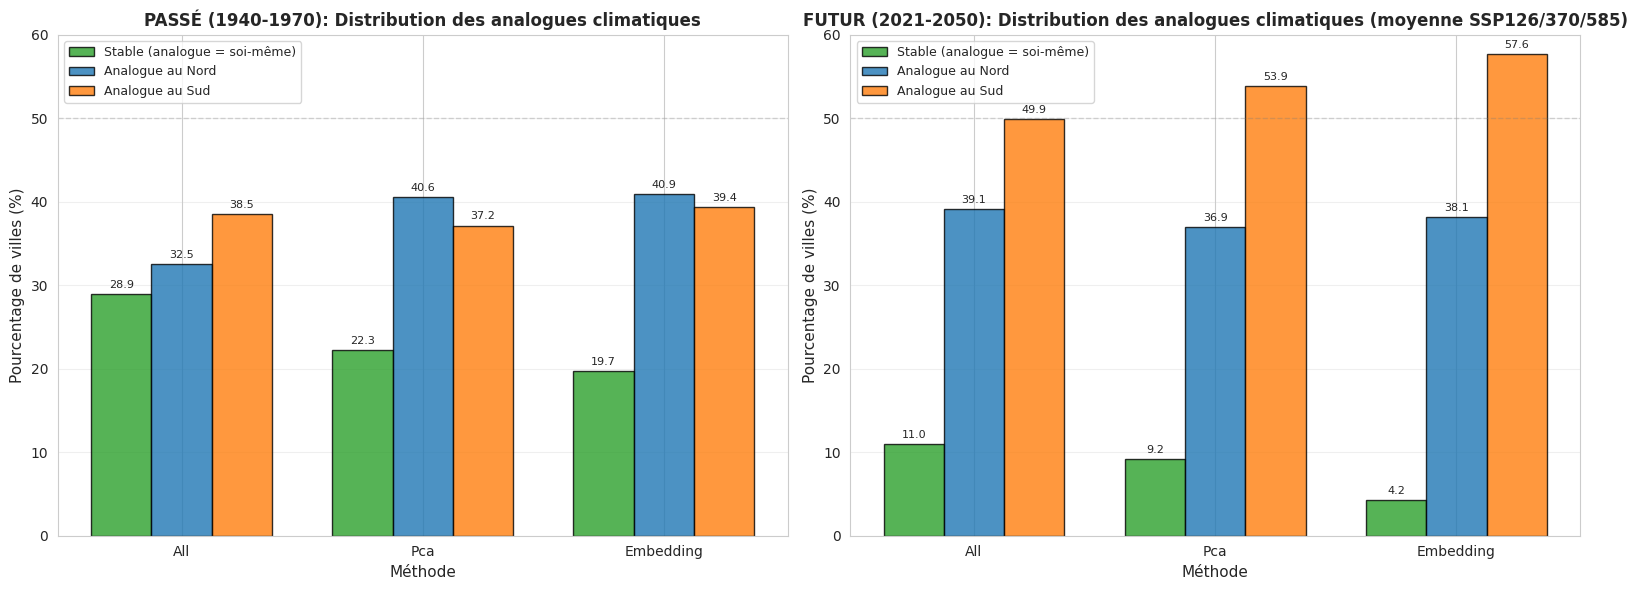

Figure sauvegardée: images/best_analog_analysis.png

RÉSUMÉ VISUEL:
PASSÉ:  Stable 23.6% | Nord 38.0% | Sud 38.4%
FUTUR:  Stable 8.1% | Nord 38.1% | Sud 53.8%

→ Stable: 23.6% → 8.1% (Δ -15.5 points)
→ Sud:    38.4% → 53.8% (Δ +15.4 points)


In [19]:
# Visualisation complète : Stable, Nord, Sud pour Passé et Futur
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods = ['all', 'pca', 'embedding']
x = np.arange(len(methods))
width = 0.25  # Largeur de chaque barre (3 catégories)

# Calculer les moyennes par méthode
pct_stable_past = geo_summary_k1.groupby('method')['pct_same_past'].mean()
pct_north_past = geo_summary_k1.groupby('method')['pct_past_north'].mean()
pct_south_past = geo_summary_k1.groupby('method')['pct_past_south'].mean()

pct_stable_future = geo_summary_k1.groupby('method')['pct_same_future'].mean()
pct_north_future = geo_summary_k1.groupby('method')['pct_future_north'].mean()
pct_south_future = geo_summary_k1.groupby('method')['pct_future_south'].mean()

# ============================================================================
# Graphique 1 : PASSÉ (1940-1970)
# ============================================================================
ax1 = axes[0]

bars_stable_past = ax1.bar(x - width, pct_stable_past.values, width, 
                            label='Stable (analogue = soi-même)', 
                            color='#2ca02c', alpha=0.8, edgecolor='black')
bars_north_past = ax1.bar(x, pct_north_past.values, width, 
                          label='Analogue au Nord', 
                          color='#1f77b4', alpha=0.8, edgecolor='black')
bars_south_past = ax1.bar(x + width, pct_south_past.values, width, 
                          label='Analogue au Sud', 
                          color='#ff7f0e', alpha=0.8, edgecolor='black')

ax1.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.3)
ax1.set_ylabel('Pourcentage de villes (%)', fontsize=11)
ax1.set_xlabel('Méthode', fontsize=11)
ax1.set_title('PASSÉ (1940-1970): Distribution des analogues climatiques', 
              fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.capitalize() for m in methods])
ax1.set_ylim(0, 60)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bars in [bars_stable_past, bars_north_past, bars_south_past]:
    for bar in bars:
        height = bar.get_height()
        if height > 2:  # Afficher seulement si > 2%
            ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=8)

# ============================================================================
# Graphique 2 : FUTUR (2021-2050)
# ============================================================================
ax2 = axes[1]

bars_stable_future = ax2.bar(x - width, pct_stable_future.values, width, 
                              label='Stable (analogue = soi-même)', 
                              color='#2ca02c', alpha=0.8, edgecolor='black')
bars_north_future = ax2.bar(x, pct_north_future.values, width, 
                            label='Analogue au Nord', 
                            color='#1f77b4', alpha=0.8, edgecolor='black')
bars_south_future = ax2.bar(x + width, pct_south_future.values, width, 
                            label='Analogue au Sud', 
                            color='#ff7f0e', alpha=0.8, edgecolor='black')

ax2.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.3)
ax2.set_ylabel('Pourcentage de villes (%)', fontsize=11)
ax2.set_xlabel('Méthode', fontsize=11)
ax2.set_title('FUTUR (2021-2050): Distribution des analogues climatiques (moyenne SSP126/370/585)', 
              fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.capitalize() for m in methods])
ax2.set_ylim(0, 60)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bars in [bars_stable_future, bars_north_future, bars_south_future]:
    for bar in bars:
        height = bar.get_height()
        if height > 2:  # Afficher seulement si > 2%
            ax2.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('images/best_analog_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure sauvegardée: images/best_analog_analysis.png")
print("\n" + "="*80)
print("RÉSUMÉ VISUEL:")
print("="*80)
print(f"PASSÉ:  Stable {pct_stable_past.mean():.1f}% | Nord {pct_north_past.mean():.1f}% | Sud {pct_south_past.mean():.1f}%")
print(f"FUTUR:  Stable {pct_stable_future.mean():.1f}% | Nord {pct_north_future.mean():.1f}% | Sud {pct_south_future.mean():.1f}%")
print(f"\n→ Stable: {pct_stable_past.mean():.1f}% → {pct_stable_future.mean():.1f}% (Δ {pct_stable_future.mean()-pct_stable_past.mean():.1f} points)")
print(f"→ Sud:    {pct_south_past.mean():.1f}% → {pct_south_future.mean():.1f}% (Δ +{pct_south_future.mean()-pct_south_past.mean():.1f} points)")